## **Estimating a mean difference for paired data**

Did the average unemployment rate change significantly in the same Colombian departments between 2024 and 2025, using DANE labor-market data?

Institution: DANE
Data: Employment and unemployment statistics
Unit of analysis: Department
Paired variable:

Statistical method: Paired t-test

Why this is paired data:
 Each department is measured twice, so every 2024 value is directly matched with the same department’s 2025 value.

DANE publishes official Colombian labor-market statistics, including unemployment indicators.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# ------------------------------------------------------------
# 1. Load Excel file
# ------------------------------------------------------------

file_path = "/content/drive/MyDrive/python/DataSet/anex-GEIHDepartamentos-2025.xls"

df_raw = pd.read_excel(
    file_path,
    sheet_name="Departamentos anual",
    header=None
)

# ------------------------------------------------------------
# 2. Identify department blocks
# ------------------------------------------------------------

department_rows = []

for i in range(len(df_raw) - 1):
    current_value = df_raw.iloc[i, 0]

    if pd.notna(current_value):
        current_value = str(current_value).strip()

        # A department row has a name in column 0,
        # empty values in the rest of the row,
        # and the next row says "Concepto"
        rest_of_row_empty = df_raw.iloc[i, 1:].isna().all()

        next_value = df_raw.iloc[i + 1, 0]
        next_is_concepto = (
            pd.notna(next_value)
            and str(next_value).strip().lower() == "concepto"
        )

        if current_value != "" and rest_of_row_empty and next_is_concepto:
            department_rows.append((i, current_value))

print("Departments found:", len(department_rows))
print(department_rows[:5])

Departments found: 23
[(9, 'Antioquia'), (27, 'Atlántico'), (45, 'Bolívar'), (63, 'Boyacá'), (81, 'Caldas')]


In [ ]:
# ------------------------------------------------------------
# 3. Extract Tasa de Desocupación (TD)
# ------------------------------------------------------------

records = []

for dept_start_row, department in department_rows:

    # The year row is usually two rows after the department name
    year_row = dept_start_row + 2
    years = df_raw.iloc[year_row, 1:].tolist()

    # Search inside the department block for Tasa de Desocupación
    for row in range(dept_start_row + 3, min(dept_start_row + 15, len(df_raw))):

        concept = df_raw.iloc[row, 0]

        if pd.notna(concept):
            concept_clean = str(concept).strip().lower()

            if "tasa de desocupación" in concept_clean:
                values = df_raw.iloc[row, 1:].tolist()

                for year, value in zip(years, values):
                    if pd.notna(year) and pd.notna(value):
                        records.append({
                            "Departamento": department,
                            "Year": int(float(year)),
                            "TD": float(value)
                        })

                break

td_long = pd.DataFrame(records)

td_long.head()

,Departamento,Year,TD
0,Antioquia,2007,11.441252
1,Antioquia,2008,12.332221
2,Antioquia,2009,12.996154
3,Antioquia,2010,11.992692
4,Antioquia,2011,10.769564


In [ ]:
# ------------------------------------------------------------
# 4. Create wide table for 2024 vs 2025
# ------------------------------------------------------------

td_wide = (
    td_long
    .pivot(index="Departamento", columns="Year", values="TD")
    .reset_index()
)

td_comparison = td_wide[["Departamento", 2024, 2025]].copy()

td_comparison["Difference_2025_minus_2024"] = (
    td_comparison[2025] - td_comparison[2024]
)

td_comparison.head()

Year,Departamento,2024,2025,Difference_2025_minus_2024
0,Antioquia,9.407142,7.508917,-1.898225
1,Atlántico,9.453107,8.505265,-0.947842
2,Bolívar,10.473692,9.382644,-1.091048
3,Boyacá,8.672565,9.329534,0.656969
4,Caldas,9.374001,9.105212,-0.268789


In [ ]:
# ------------------------------------------------------------
# 5. Paired t-test
# ------------------------------------------------------------

diff = td_comparison["Difference_2025_minus_2024"]



t_stat, p_value = stats.ttest_rel(
    td_comparison[2025],
    td_comparison[2024]
)

n = len(diff)
mean_diff = diff.mean()
std_diff = diff.std(ddof=1)
se_diff = std_diff / np.sqrt(n)

alpha = 0.05
t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)

ci_lower = mean_diff - t_critical * se_diff
ci_upper = mean_diff + t_critical * se_diff

print("Paired t-test: TD 2025 vs TD 2024")
print("----------------------------------")
print(f"Number of departments: {n}")
print(f"Average TD in 2024: {td_comparison[2024].mean():.2f}")
print(f"Average TD in 2025: {td_comparison[2025].mean():.2f}")
print(f"Mean difference 2025 - 2024: {mean_diff:.2f}")
print(f"t statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.5f}")
print(f"95% CI for mean difference: [{ci_lower:.2f}, {ci_upper:.2f}]")

Paired t-test: TD 2025 vs TD 2024
----------------------------------
Number of departments: 23
Average TD in 2024: 10.67
Average TD in 2025: 9.47
Mean difference 2025 - 2024: -1.21
t statistic: -5.689
p-value: 0.00001
95% CI for mean difference: [-1.65, -0.77]


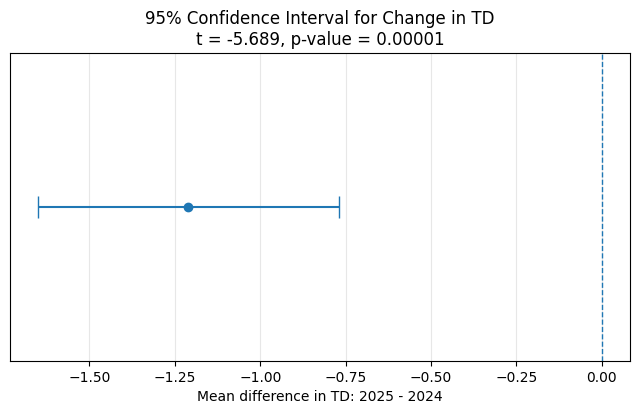

In [ ]:
import matplotlib.pyplot as plt

mean_diff = -1.21
ci_lower = -1.65
ci_upper = -0.77
p_value = 0.00001
t_stat = -5.689

plt.figure(figsize=(8, 4))

plt.errorbar(
    x=mean_diff,
    y=0,
    xerr=[[mean_diff - ci_lower], [ci_upper - mean_diff]],
    fmt="o",
    capsize=8
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.yticks([])
plt.xlabel("Mean difference in TD: 2025 - 2024")
plt.title(
    f"95% Confidence Interval for Change in TD\n"
    f"t = {t_stat:.3f}, p-value = {p_value:.5f}"
)

plt.grid(axis="x", alpha=0.3)

plt.show()

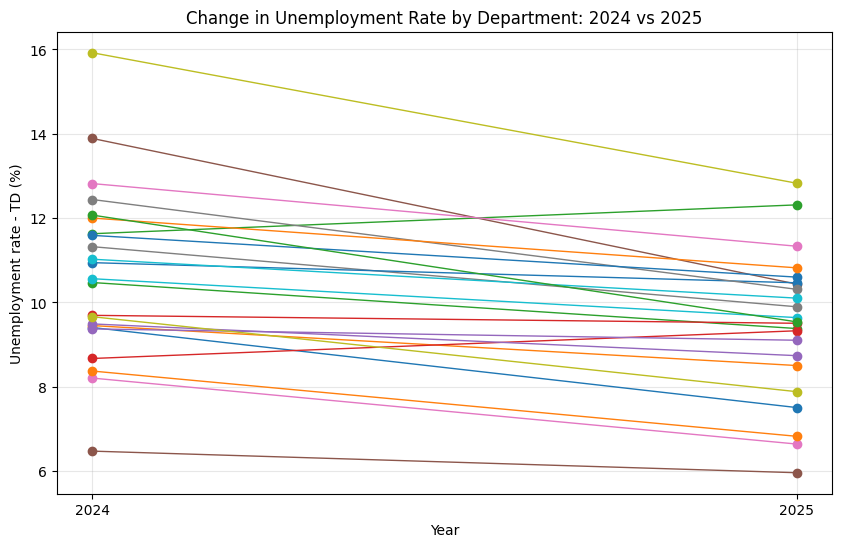

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for _, row in td_comparison.iterrows():
    plt.plot(
        [2024, 2025],
        [row[2024], row[2025]],
        marker="o",
        linewidth=1
    )

plt.xticks([2024, 2025])
plt.xlabel("Year")
plt.ylabel("Unemployment rate - TD (%)")
plt.title("Change in Unemployment Rate by Department: 2024 vs 2025")
plt.grid(True, alpha=0.3)

plt.show()

The data suggest that the average unemployment rate changed significantly between 2024 and 2025 across the same Colombian departments. Specifically, the unemployment rate decreased by approximately 1.21 percentage points on average.